In [1]:
import numpy as np

# Inputs / Assumptions
# initial value of portfolio (what you start with)
initial_value = 100_000
# investment horizon
years = 10
# mean annual return
expected_return = 0.07
# annual volatility (standard deviation of returns)
volatility = 0.15
# portfolio value you want to reach (goal)
target_value = 200_000
# number of Monte Carlo runs
n_simulations = 10_000
# fixes randomness, so results are reproducible
seed = 42

rng = np.random.default_rng(seed)
print('Setup ready, inputs defined.')

Setup ready, inputs defined.


In [2]:
# converting to log space parameters
mu = expected_return
sigma = volatility

log_mu = np.log(1 + mu) - 0.5 * np.log(1+(sigma**2)/(1 + mu)**2)
log_sigma = np.sqrt(np.log(1+(sigma**2)/ (1 + mu)**2))

growth_factors = np.exp(rng.normal(log_mu, log_sigma, size=(n_simulations, years)))

print('Shape:', growth_factors.shape)
print("\nFirst simulations's 10 growth factors:")
print(growth_factors[0].round(3))
print('\nMin growth factor in whole grid:', growth_factors.min().round(4))
print('Mean implied return:',(growth_factors.mean()-1).round(4))

Shape: (10000, 10)

First simulations's 10 growth factors:
[1.106 0.917 1.177 1.208 0.807 0.884 1.079 1.014 1.057 0.941]

Min growth factor in whole grid: 0.5744
Mean implied return: 0.0694


In [3]:
cumulative_growth = np.cumprod(growth_factors, axis = 1)
paths = initial_value * cumulative_growth
start_column = np.full((n_simulations, 1), initial_value)
paths = np.hstack([start_column, paths])

print('Paths shape:', paths.shape)
print("\nFirst simulation's value each year (rounded):")
print(paths[0].round(2))
print(f'\nYear 0 of every path should be {initial_value}:', np.all(paths[:,0]==initial_value))

Paths shape: (10000, 11)

First simulation's value each year (rounded):
[100000.   110565.45 101337.04 119232.07 144057.63 116275.37 102742.71
 110829.18 112370.37 118793.21 111754.87]

Year 0 of every path should be 100000: True


In [4]:
# each simulation's year 10 portfolio value
terminal_values = paths[:, -1]

# portfolios that finished at target value or above
hit_target = terminal_values >= target_value
prob_attainment = hit_target.mean()

# percentiles of final values
p10 = np.percentile(terminal_values, 10)
p50 = np.percentile(terminal_values, 50)
p90 = np.percentile(terminal_values, 90)

print(f'Target: ${target_value}')
print(f'Probability of reaching target: {prob_attainment:.1%}')
print(f"P10 (pessimistic):${p10:,.0f}")
print(f"P50 (median):${p50:,.0f}")
print(f"P90 (optimistic):${p90:,.0f}")
print(f"Mean:${terminal_values.mean():,.0f}")

Target: $200000
Probability of reaching target: 39.2%
P10 (pessimistic):$100,715
P50 (median):$176,221
P90 (optimistic):$316,741
Mean:$195,774


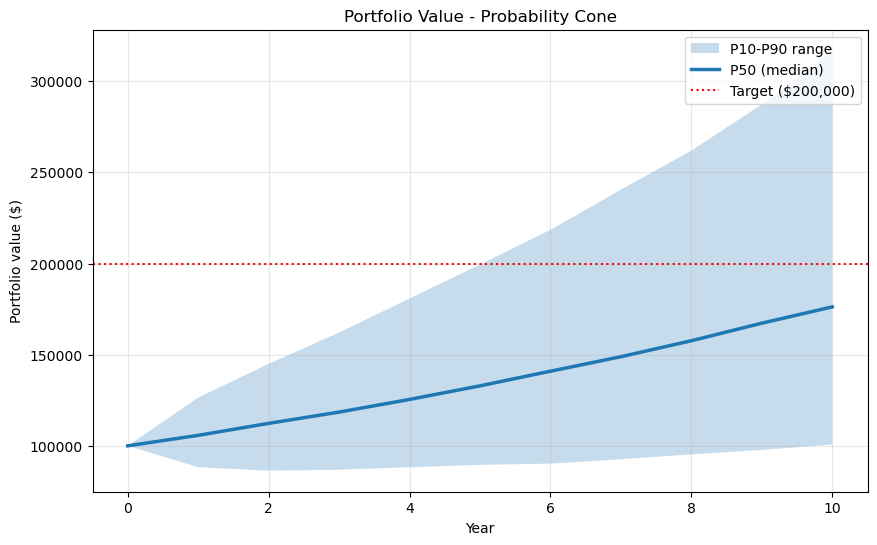

In [12]:
import matplotlib.pyplot as plt

years_axis = np.arange(years+1)
# percentiles computed every year
cone_p10 = np.percentile(paths, 10, axis=0) 
cone_p50 = np.percentile(paths, 50, axis=0)
cone_p90 = np.percentile(paths, 90, axis=0)

fig, ax = plt.subplots(figsize=(10,6))

# adding shading band between p10 and p90
ax.fill_between(years_axis, cone_p10, cone_p90, alpha=0.25, label='P10-P90 range')

# adding median line
ax.plot(years_axis, cone_p50, linewidth=2.5, label='P50 (median)')

# target reference line
ax.axhline(target_value, color='red', linestyle=':', label=f"Target (${target_value:,.0f})")

ax.set_title("Portfolio Value - Probability Cone")
ax.set_xlabel("Year")
ax.set_ylabel("Portfolio value ($)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig("probability_cone.png", dpi=150, bbox_inches="tight")
plt.show()

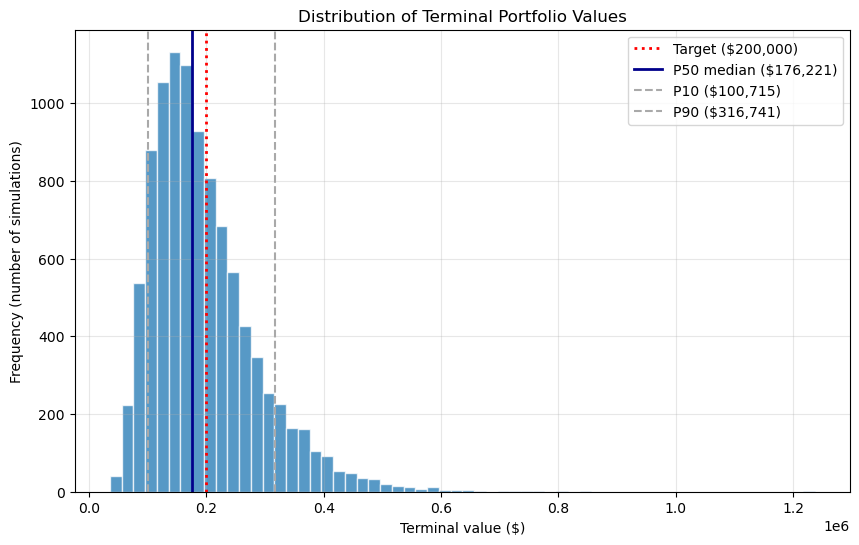

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# histogram of the 10,000 final values, split into 60 bins
ax.hist(terminal_values, bins=60, alpha=0.75, edgecolor="white")

# mark target and key percentiles.
ax.axvline(target_value, color="red", linestyle=":", linewidth=2, label=f"Target (${target_value:,.0f})")
ax.axvline(p50, color="darkblue", linewidth=2, label=f"P50 median (${p50:,.0f})")
ax.axvline(p10, color="darkgray", linestyle="--", label=f"P10 (${p10:,.0f})")
ax.axvline(p90, color="darkgray", linestyle="--", label=f"P90 (${p90:,.0f})")

ax.set_title("Distribution of Terminal Portfolio Values")
ax.set_xlabel("Terminal value ($)")
ax.set_ylabel("Frequency (number of simulations)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig("terminal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.drawing.image import Image as XLImage

wb = Workbook()

# Sheet 1: Summary 
ws = wb.active
ws.title = "Summary"
ws["A1"] = "Monte Carlo Portfolio Simulation"
ws["A1"].font = Font(bold=True, size=14)

# Model Assumptions
ws["A3"] = "Assumptions"
ws["A3"].font = Font(bold=True, size=12)
# (label, value, number_format)
assumptions = [
    ("Initial value ($)", initial_value, '$#,##0'),
    ("Horizon (years)", years, '0'),
    ("Expected return", expected_return, '0.0%'),
    ("Volatility", volatility, '0.0%'),
    ("Target value ($)", target_value, '$#,##0'),
    ("Simulations", n_simulations, '#,##0'),
]
row = 4
for label, val, fmt in assumptions:
    ws[f"A{row}"] = label
    c = ws[f"B{row}"]
    c.value = val
    c.font = Font(color="0000FF")
    c.number_format = fmt
    row += 1

# Results
row += 1
ws[f"A{row}"] = "Results"
ws[f"A{row}"].font = Font(bold=True, size=12)
row += 1
results = [
    ("Probability of reaching target", prob_attainment, '0.0%'),
    ("P10 (pessimistic)", p10, '$#,##0'),
    ("P50 (median)", p50, '$#,##0'),
    ("P90 (optimistic)", p90, '$#,##0'),
    ("Mean", terminal_values.mean(), '$#,##0'),
]
for label, val, fmt in results:
    ws[f"A{row}"] = label
    c = ws[f"B{row}"]
    c.value = round(float(val), 4)
    c.number_format = fmt
    row += 1

ws.column_dimensions["A"].width = 32
ws.column_dimensions["B"].width = 16
    
# Sheet 2: Cone data
ws2 = wb.create_sheet("Cone Data")
for col, h in enumerate(["Year", "P10", "P50", "P90"], start=1):
    c = ws2.cell(row=1, column=col, value=h)
    c.font = Font(bold=True, color="FFFFFF")
    c.fill = PatternFill("solid", fgColor="1B4FB3")
for i in range(len(years_axis)):
    ws2.cell(row=i+2, column=1, value=int(years_axis[i]))
    for col, arr in zip((2, 3, 4), (cone_p10, cone_p50, cone_p90)):
        c = ws2.cell(row=i+2, column=col, value=round(float(arr[i]), 2))
        c.number_format = '$#,##0'
for col in "BCD":
    ws2.column_dimensions[col].width = 14
    

# Sheet 3: Adding graphs
ws3 = wb.create_sheet("Charts")
ws3["A1"] = "Probability Cone"
ws3["A1"].font = Font(bold=True, size=12)
ws3.add_image(XLImage("probability_cone.png"), "A2")
ws3["A32"] = "Terminal Value Distribution"
ws3["A32"].font = Font(bold=True, size=12)
ws3.add_image(XLImage("terminal_distribution.png"), "A33")

wb.save("monte_carlo_results.xlsx")
print("Saved monte_carlo_results.xlsx")

Saved monte_carlo_results.xlsx
